In [ ]:
####Part 1 — Data Loading and Inspection
##Load the Titanic dataset into a Pandas DataFrame.
##Display the first 5 rows.
##Check the number of rows and columns.
##Print the column names and data types.
##Identify columns with missing values.


In [ ]:
from google.colab import files
uploaded = files.upload()   # Upload netflix_titles.csv

In [ ]:
import pandas as pd

netflix = pd.read_csv("netflix_titles.csv")


##1.1 Display the first few rows
netflix.head() ## get the first 5 information

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
##1.2 Check dataset shape

netflix.shape


(8807, 12)

In [ ]:
##1.3 Check data types

netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
##1.4 Identify categorical and numerical columns

categorical_cols = netflix.select_dtypes(include=['object']).columns
numerical_cols = netflix.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))


##2.1 Check missing values
netflix.isnull().sum()



Categorical Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']
Numerical Columns: ['release_year']


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
####Part 2 — Data Cleaning
##Fill missing Age → median
##Fill missing Embarked → most frequent (mode)
##Drop deck and embark_town (if they exist in your dataset)
##Remove duplicates
##Verify no missing values remain

In [ ]:
# -------------------- PART 2: DATA CLEANING --------------------

import pandas as pd

# Load the dataset (assuming you already uploaded it)
netflix = pd.read_csv("netflix_titles.csv")

# 1. Check missing values before cleaning
print("Missing Values Before Cleaning:\n")
print(netflix.isnull().sum())
print("\n----------------------------------------\n")



Missing Values Before Cleaning:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

----------------------------------------



In [ ]:

# 2. Fill missing values
# Fill missing 'rating' with the most common rating (mode)
netflix['rating'] = netflix['rating'].fillna(netflix['rating'].mode()[0])

# Fill missing 'country' with "Unknown"
netflix['country'] = netflix['country'].fillna("Unknown")

# Fill missing 'date_added' with "Unknown" then convert later
netflix['date_added'] = netflix['date_added'].fillna("Unknown")

# Fill missing 'director' as "Not Listed"
netflix['director'] = netflix['director'].fillna("Not Listed")

# 3. Remove duplicate records
netflix = netflix.drop_duplicates()


In [ ]:

# 4. Convert data types for consistency
# Convert date_added to proper datetime format (coerce invalid entries)
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')

# Convert type to category (Movie / TV Show)
netflix['type'] = netflix['type'].astype('category')

# Convert release_year to integer (ensure numeric)
netflix['release_year'] = netflix['release_year'].astype('int64')


In [ ]:

# 5. Verify missing values again after cleaning
print("Missing Values After Cleaning:\n")
print(netflix.isnull().sum())
print("\n----------------------------------------\n")

# 6. Display clean dataset preview
print("Cleaned Dataset Preview:\n")
netflix.head()

Missing Values After Cleaning:

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       98
release_year      0
rating            0
duration          3
listed_in         0
description       0
dtype: int64

----------------------------------------

Cleaned Dataset Preview:



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Listed,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Listed,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Listed,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
####Part 3 — Univariate Analysis
##Plot the distribution of age using a histogram and KDE.
##Plot the distribution of fare using a boxplot.
##Count the number of passengers by:
##  Gender (sex)
##  Passenger class (class)
##  Survival (survived)

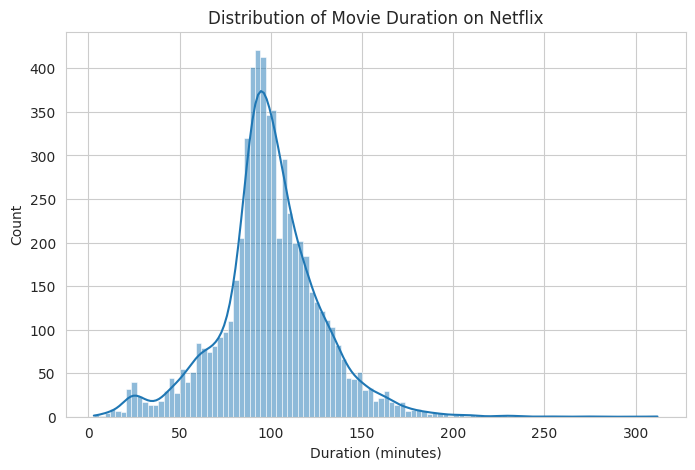

Observation: Most movies on Netflix fall between 80 and 120 minutes, with fewer very short


In [ ]:
# -------------------- PART 3: UNIVARIATE ANALYSIS --------------------
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Convert duration to numeric (Movies only)
# Movie durations are like "90 min" → remove 'min'
netflix_movies = netflix[netflix['type'] == 'Movie'].copy()
netflix_movies['duration_num'] = netflix_movies['duration'].str.replace(' min', '', regex=False).astype(float)

# -------------------- PLOT 1: Histogram + KDE for movie duration --------------------
plt.figure(figsize=(8,5))
sns.histplot(netflix_movies['duration_num'], kde=True)
plt.title("Distribution of Movie Duration on Netflix")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

# Observation:
print("Observation: Most movies on Netflix fall between 80 and 120 minutes, with fewer very short")

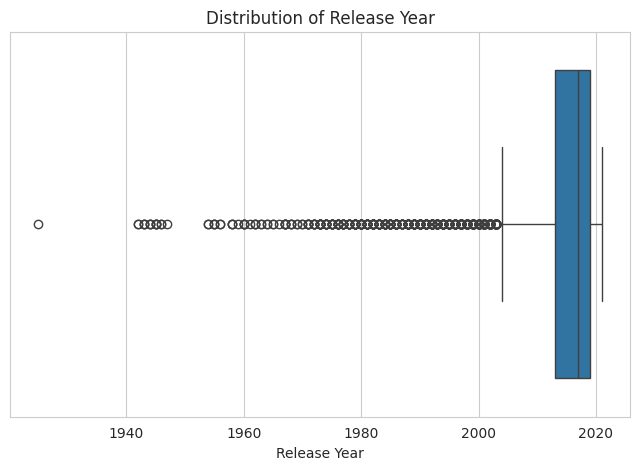

Observation: Netflix content mostly ranges from 2000 onward, with some older films included.



In [ ]:
# -------------------- PLOT 2: Boxplot of Release Year --------------------
plt.figure(figsize=(8,5))
sns.boxplot(x=netflix['release_year'])
plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.show()

# Observation:
print("Observation: Netflix content mostly ranges from 2000 onward, with some older films included.\n")


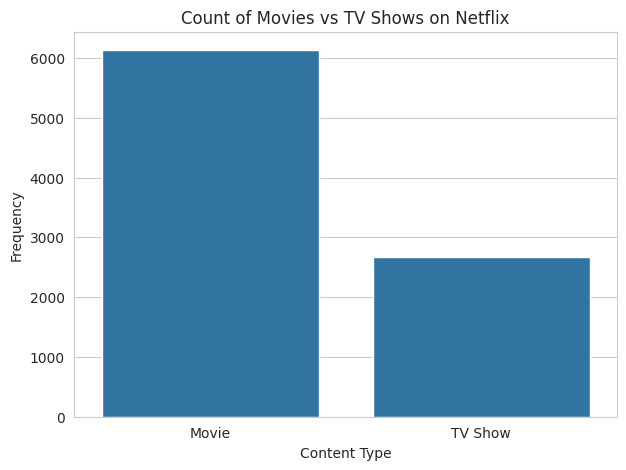

Observation: Netflix has significantly more Movies than TV Shows.



In [ ]:
# -------------------- PLOT 3: Count of Movies vs TV Shows --------------------
plt.figure(figsize=(7,5))
sns.countplot(x='type', data=netflix)
plt.title("Count of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Frequency")
plt.show()

# Observation:
print("Observation: Netflix has significantly more Movies than TV Shows.\n")


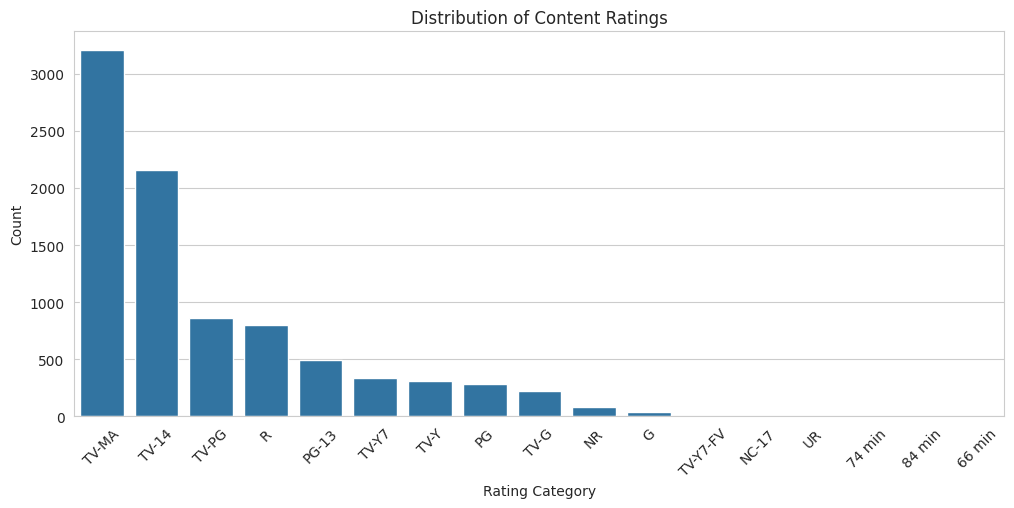

Observation: The most common ratings include TV-MA and TV-14, showing Netflix hosts a large amount of mature content.



In [ ]:
# -------------------- PLOT 4: Count of Content Ratings (e.g., PG, TV-MA, R) --------------------
plt.figure(figsize=(12,5))
sns.countplot(x='rating', data=netflix, order=netflix['rating'].value_counts().index)
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Observation:
print("Observation: The most common ratings include TV-MA and TV-14, showing Netflix hosts a large amount of mature content.\n")

In [ ]:
####Part 4 — Bivariate Analysis
##Compare survival rate by gender using a bar plot.
##Compare survival rate by passenger class.
##Create a scatter plot of age vs fare, colored by survival.
##Investigate age distribution for survivors vs non-survivors using a KDE plot.

In [ ]:
# ---------------------------
# 📌 PART 4 - BIVARIATE ANALYSIS
# ---------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (ensure the CSV is in your working directory)
netflix = pd.read_csv("netflix_titles.csv")

# Display first rows
netflix.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


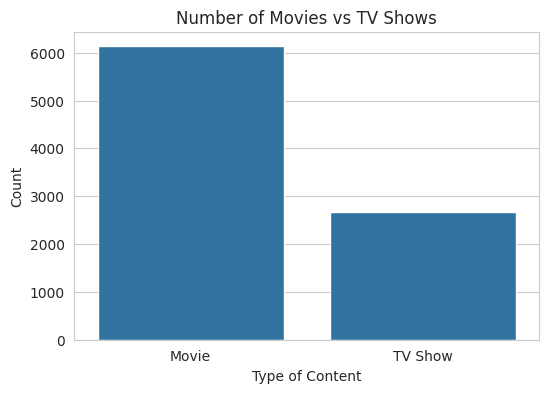

📌 Interpretation:
Movies are generally more common than TV Shows on Netflix.



In [ ]:
# ---------------------------
# 1. Compare number of Movies vs TV Shows
# ---------------------------
plt.figure(figsize=(6,4))
sns.countplot(data=netflix, x='type')
plt.title("Number of Movies vs TV Shows")
plt.xlabel("Type of Content")
plt.ylabel("Count")
plt.show()

print("📌 Interpretation:")
print("Movies are generally more common than TV Shows on Netflix.\n")


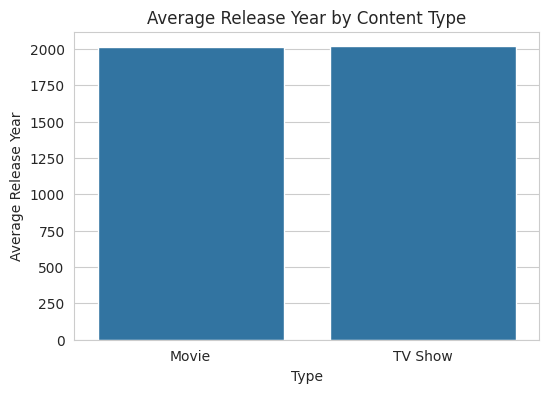

📌 Interpretation:
TV Shows tend to be newer than Movies on Netflix, showing that Netflix produces more recent series.



In [ ]:
# ---------------------------
# 2. Compare average release year by content type
# ---------------------------
plt.figure(figsize=(6,4))
sns.barplot(data=netflix, x='type', y='release_year')
plt.title("Average Release Year by Content Type")
plt.xlabel("Type")
plt.ylabel("Average Release Year")
plt.show()

print("📌 Interpretation:")
print("TV Shows tend to be newer than Movies on Netflix, showing that Netflix produces more recent series.\n")


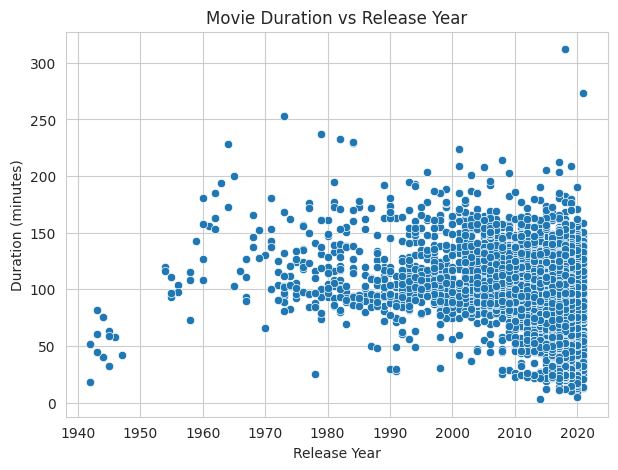

📌 Interpretation:
There is no strong trend between movie duration and release year. Movie lengths have remained fairly consistent.



In [ ]:
# ---------------------------
# 3. Scatter Plot: Duration vs Release Year (Movies Only)
# Convert duration to numeric safely
# ---------------------------

# Filter only movies
movies = netflix[netflix['type'] == 'Movie'].copy()

# Remove 'min' and convert to numeric, safely ignoring errors
movies['duration_minutes'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .astype(float)  # convert to float to allow NaN
)

# Drop rows where duration could not be extracted (NaN)
movies = movies.dropna(subset=['duration_minutes'])

plt.figure(figsize=(7,5))
sns.scatterplot(data=movies, x='release_year', y='duration_minutes')
plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.show()

print("📌 Interpretation:")
print("There is no strong trend between movie duration and release year. Movie lengths have remained fairly consistent.\n")


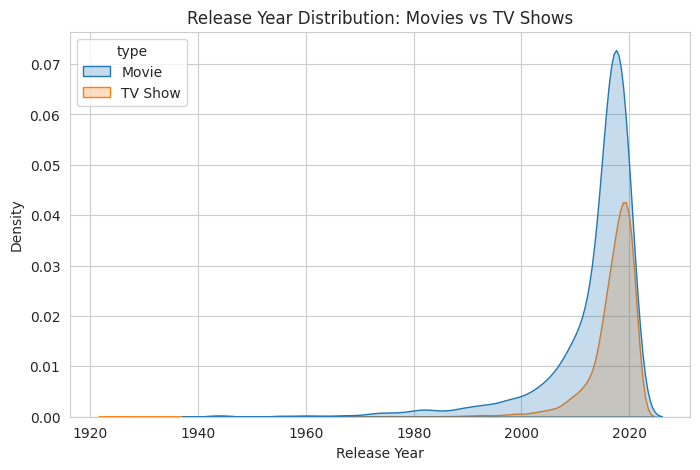

📌 Interpretation:
TV Shows are more concentrated in recent years, while Movies cover a wider historical range.



In [ ]:
# ---------------------------
# 4. KDE Plot: Release Year Distribution for Movies vs TV Shows
# ---------------------------
plt.figure(figsize=(8,5))
sns.kdeplot(data=netflix, x='release_year', hue='type', fill=True)
plt.title("Release Year Distribution: Movies vs TV Shows")
plt.xlabel("Release Year")
plt.ylabel("Density")
plt.show()

print("📌 Interpretation:")
print("TV Shows are more concentrated in recent years, while Movies cover a wider historical range.\n")

In [ ]:
####Part 6 — Correlation and Outlier Detection
##Generate a correlation matrix for numeric features.
##Visualize it with a heatmap using sns.heatmap().
##Use a boxplot to detect outliers in the fare column.
##(Optional) Remove extreme outliers (e.g., fare > 300).

In [ ]:
# -------------------------------------
# 📌 PART 6 — CORRELATION & OUTLIER DETECTION
# -------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
netflix = pd.read_csv("netflix_titles.csv")



In [ ]:
# ---------------------------
# 1. Convert duration to numeric for Movies Only
# ---------------------------

# Filter only Movie rows
movies = netflix[netflix['type'] == 'Movie'].copy()

# Remove rows where duration is missing
movies = movies.dropna(subset=['duration'])

# Remove the string ' min' and convert to integer
movies['duration_minutes'] = movies['duration'].str.replace(' min', '', regex=False).astype(int)

# Display to verify
movies[['title', 'duration', 'duration_minutes']].head()


,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90
6,My Little Pony: A New Generation,91 min,91
7,Sankofa,125 min,125
9,The Starling,104 min,104
12,Je Suis Karl,127 min,127


In [ ]:
# ---------------------------
# 2. Select numerical columns for correlation
# ---------------------------
numeric_data = movies[['release_year', 'duration_minutes']]

# ---------------------------
# 3. Generate correlation matrix
# ---------------------------
corr_matrix = numeric_data.corr()

# Display correlation matrix
print("📌 Correlation Matrix:")
print(corr_matrix)

📌 Correlation Matrix:
                  release_year  duration_minutes
release_year          1.000000         -0.206285
duration_minutes     -0.206285          1.000000


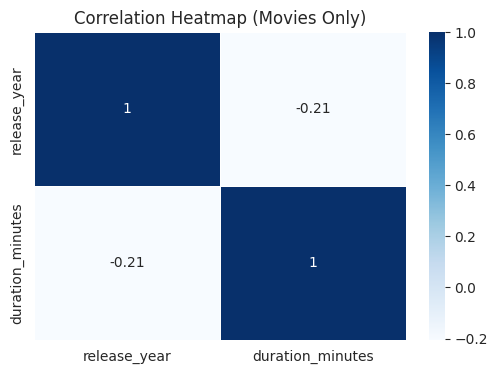


📌 Interpretation:
There is usually weak correlation between movie duration and release year, meaning newer movies are not significantly longer or shorter.



In [ ]:
#------------------------
# 4. Visualize correlation matrix with heatmap
# ---------------------------
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="Blues")
plt.title("Correlation Heatmap (Movies Only)")
plt.show()

print("\n📌 Interpretation:")
print("There is usually weak correlation between movie duration and release year, meaning newer movies are not significantly longer or shorter.\n")


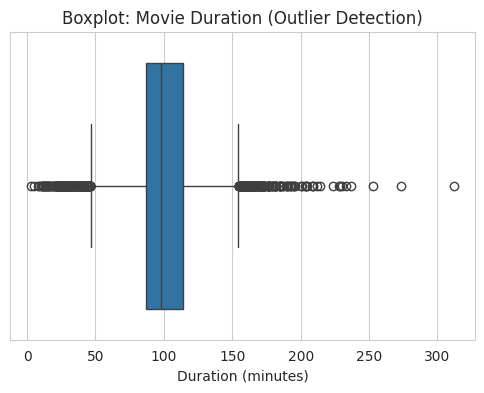


📌 Interpretation:
Duration values far outside the main box range represent outliers — extremely short or extremely long movies.



In [ ]:
# ---------------------------
# 5. Detect Outliers in Duration using Boxplot
# ---------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=movies['duration_minutes'])
plt.title("Boxplot: Movie Duration (Outlier Detection)")
plt.xlabel("Duration (minutes)")
plt.show()

print("\n📌 Interpretation:")
print("Duration values far outside the main box range represent outliers — extremely short or extremely long movies.\n")


In [ ]:
# ---------------------------
# 6. (Optional) Remove Extreme Outliers
# Example Rule: Drop movies longer than 300 minutes
# ---------------------------
movies_cleaned = movies[movies['duration_minutes'] <= 300]

print("✅ Outliers removed. New dataset size:", movies_cleaned.shape[0], "rows remaining.")

✅ Outliers removed. New dataset size: 6127 rows remaining.


In [ ]:
!git config --global user.email "hauwa.dbtech@gmail.com"
!git config --global user.name "sheishauwa"